In [6]:
from google.colab import drive
import gzip
import random
import networkx as nx
from collections import deque
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

drive.mount('/content/drive')

%cd /content/drive/MyDrive/Colab Notebooks/AM

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/AM


In [2]:
adj = {}

with gzip.open('web-Google.txt.gz', 'rt') as f:
  for line in f:
    if line.startswith('#'):
      continue
    u, v = map(int, line.split())
    adj.setdefault(u, []).append(v)
    adj.setdefault(v, []) # ensure node exists

start = random.choice(list(adj.keys()))
visited = set([start])
queue = deque([start])

while queue and len(visited) < 300:
  node = queue.popleft()
  for neighbor in adj.get(node, []):
    if neighbor not in visited:
      visited.add(neighbor)
      queue.append(neighbor)
    if len(visited) >= 300:
      break

# keep edges inside sampled nodes
sample_edges = [(u, v) for u in visited for v in adj.get(u, []) if v in visited]

In [3]:
G = nx.DiGraph()
G.add_nodes_from(visited)
G.add_edges_from(sample_edges)

print(f"Nodes: {nx.number_of_nodes(G)}, Vertices: {nx.number_of_edges(G)}")

Nodes: 300, Vertices: 1375


In [4]:
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())
normalized_degrees = dict()

print("Some nodes in-degree, out-degree, and normalized degree:")
for node in list(G.nodes())[:10]:
  in_degree = in_degrees[node]
  out_degree = out_degrees[node]
  normalized_in = in_degree / nx.number_of_nodes(G)
  normalized_out = out_degree / nx.number_of_nodes(G)
  normalized_degrees[node] = (normalized_in, normalized_out)

  print(f"Node {node}: in-degree={in_degrees[node]}, out-degree={out_degrees[node]}, normalized degrees (in, out)={normalized_degrees[node]}")

avg_in = sum(in_degrees.values()) / len(in_degrees)
avg_out = sum(out_degrees.values()) / len(out_degrees)

print(f"\nAverage in-degree: {avg_in:.2f}, Average out-degree: {avg_out:.2f}")

Some nodes in-degree, out-degree, and normalized degree:
Node 881666: in-degree=1, out-degree=1, normalized degrees (in, out)=(0.0033333333333333335, 0.0033333333333333335)
Node 596995: in-degree=2, out-degree=3, normalized degrees (in, out)=(0.006666666666666667, 0.01)
Node 491526: in-degree=2, out-degree=9, normalized degrees (in, out)=(0.006666666666666667, 0.03)
Node 180743: in-degree=1, out-degree=8, normalized degrees (in, out)=(0.0033333333333333335, 0.02666666666666667)
Node 228874: in-degree=1, out-degree=0, normalized degrees (in, out)=(0.0033333333333333335, 0.0)
Node 604171: in-degree=2, out-degree=8, normalized degrees (in, out)=(0.006666666666666667, 0.02666666666666667)
Node 349710: in-degree=1, out-degree=3, normalized degrees (in, out)=(0.0033333333333333335, 0.01)
Node 718352: in-degree=2, out-degree=7, normalized degrees (in, out)=(0.006666666666666667, 0.023333333333333334)
Node 728594: in-degree=1, out-degree=1, normalized degrees (in, out)=(0.0033333333333333335, 

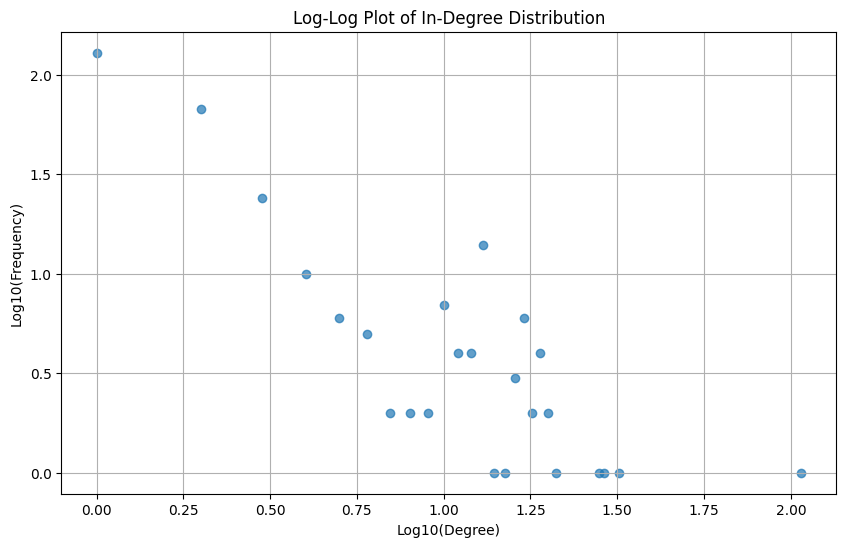

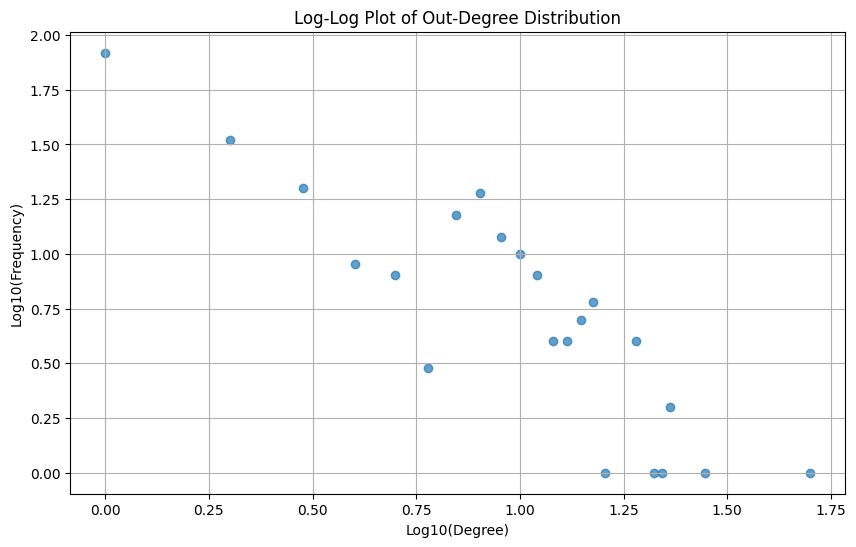

In [5]:


in_degree_counts = Counter(in_degrees.values())
out_degree_counts = Counter(out_degrees.values())

def plot_degree_distribution(degree_counts, title):
  degrees = sorted(degree_counts.keys())
  counts = [degree_counts[d] for d in degrees]

  # Filter out degrees with zero counts for log plot
  positive_counts = [(d, c) for d, c in zip(degrees, counts) if d > 0 and c > 0]
  if not positive_counts:
    print(f"No positive degree counts to plot for {title}")
    return

  log_degrees = [np.log10(d) for d, _ in positive_counts]
  log_counts = [np.log10(c) for _, c in positive_counts]

  plt.figure(figsize=(10, 6))
  plt.scatter(log_degrees, log_counts, alpha=0.7)
  plt.title(f'Log-Log Plot of {title} Distribution')
  plt.xlabel('Log10(Degree)')
  plt.ylabel('Log10(Frequency)')
  plt.grid(True)
  plt.show()

plot_degree_distribution(in_degree_counts, 'In-Degree')
plot_degree_distribution(out_degree_counts, 'Out-Degree')

In [7]:
pagerank_scores = nx.pagerank(G)
sorted_pagerank = sorted(pagerank_scores.items(), key=lambda item: item[1], reverse=True)

print("Top 10 Hubs based on PageRank, In-Degree, and Out-Degree:")
for i, (node, pr_score) in enumerate(sorted_pagerank[:10]):
  in_deg = G.in_degree(node)
  out_deg = G.out_degree(node)
  print(f"Node {node}: PageRank={pr_score:.4f}, In-Degree={in_deg}, Out-Degree={out_deg}")

Top 10 Hubs based on PageRank, In-Degree, and Out-Degree:
Node 354640: PageRank=0.0768, In-Degree=107, Out-Degree=23
Node 541100: PageRank=0.0293, In-Degree=29, Out-Degree=19
Node 460683: PageRank=0.0286, In-Degree=28, Out-Degree=19
Node 748089: PageRank=0.0177, In-Degree=11, Out-Degree=15
Node 503: PageRank=0.0173, In-Degree=12, Out-Degree=14
Node 612256: PageRank=0.0136, In-Degree=32, Out-Degree=2
Node 337605: PageRank=0.0125, In-Degree=20, Out-Degree=2
Node 474660: PageRank=0.0118, In-Degree=19, Out-Degree=9
Node 129134: PageRank=0.0116, In-Degree=21, Out-Degree=19
Node 516240: PageRank=0.0115, In-Degree=2, Out-Degree=2


Strong hub dominance is prevalent. For example, the top nodes above for the most part have very high in-degrees.

The best ranked graph has a much higher PageRank and in-degree compared to even the rest of the top 10.

Barabási-Albert Baseline Graph properties (n=300, m=5):
  Nodes: 300, Edges: 1475
  Average degree: 9.83

Plotting degree distribution for Barabási-Albert Graph:


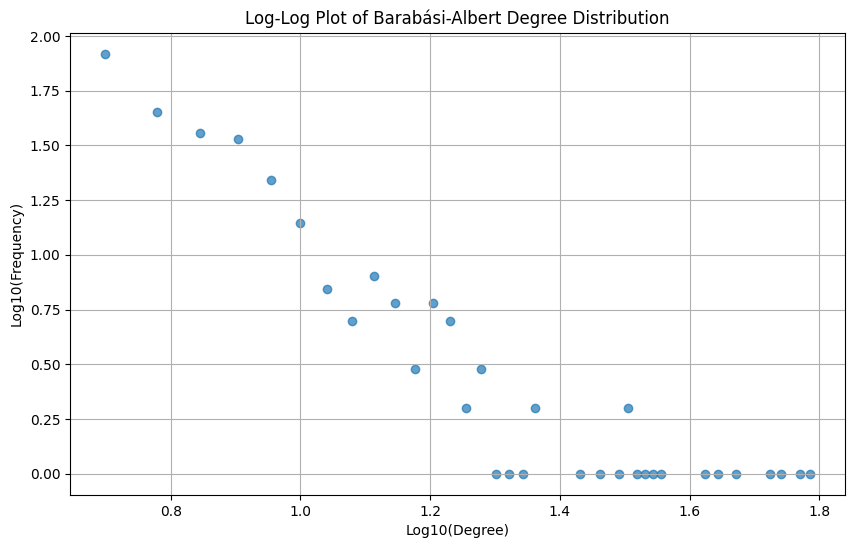


Top 10 Hubs based on PageRank in Barabási-Albert Graph:
Node 3: PageRank=0.0183, Degree=61
Node 6: PageRank=0.0172, Degree=59
Node 11: PageRank=0.0165, Degree=55
Node 8: PageRank=0.0159, Degree=53
Node 13: PageRank=0.0143, Degree=47
Node 7: PageRank=0.0132, Degree=44
Node 1: PageRank=0.0126, Degree=42
Node 14: PageRank=0.0108, Degree=36
Node 10: PageRank=0.0107, Degree=35
Node 9: PageRank=0.0101, Degree=34


In [8]:
n_nodes_G = nx.number_of_nodes(G)
n_edges_G = nx.number_of_edges(G)

# Determine 'm' for the BA model. 'm' is the number of edges each new node attaches to.
# For an undirected BA graph, the total number of edges is roughly m * (n-m).
# We'll try to match the number of edges of our directed graph G.
# Since G is directed, it has n_edges_G directed edges.
# An undirected BA graph with m_ba would have m_ba * (n_nodes_G - m_ba) edges.
m_ba = max(1, int(round(n_edges_G / n_nodes_G)))

G_ba = nx.barabasi_albert_graph(n_nodes_G, m_ba)
print(f"Barabási-Albert Baseline Graph properties (n={n_nodes_G}, m={m_ba}):")
print(f"  Nodes: {nx.number_of_nodes(G_ba)}, Edges: {nx.number_of_edges(G_ba)}")
print(f"  Average degree: {2 * nx.number_of_edges(G_ba) / nx.number_of_nodes(G_ba):.2f}")

ba_degrees = dict(G_ba.degree())
ba_degree_counts = Counter(ba_degrees.values())

print("\nPlotting degree distribution for Barabási-Albert Graph:")
plot_degree_distribution(ba_degree_counts, 'Barabási-Albert Degree')

G_ba_directed = nx.DiGraph(G_ba)
ba_pagerank_scores = nx.pagerank(G_ba_directed)
sorted_ba_pagerank = sorted(ba_pagerank_scores.items(), key=lambda item: item[1], reverse=True)

print("\nTop 10 Hubs based on PageRank in Barabási-Albert Graph:")
for i, (node, pr_score) in enumerate(sorted_ba_pagerank[:10]):
  ba_degree = G_ba.degree(node) # Use undirected degree for comparison here
  print(f"Node {node}: PageRank={pr_score:.4f}, Degree={ba_degree}")


A preferential attachment story makes sense for this domain, as the observed heavy-tailed degree distributions for both in-degree and out-degree, along with the strong hub dominance evident in the PageRank results of the sampled web graph, are all characteristics of networks formed in this way.